**PASO 1: Carga del conjunto de datos**

In [1]:
!pip install statsmodels pmdarima scikit-learn joblib -q

In [1]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import os

In [4]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv'
df = pd.read_csv(url)

In [5]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [25]:
df.tail()

,sales
date,
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415
2023-09-02,997.350214
2023-09-03,1000.482785


In [6]:
print(f'Shape: {df.shape}')

Shape: (366, 2)


In [7]:
print(f'\nTipos de datos:\n{df.dtypes}')


Tipos de datos:
date         str
sales    float64
dtype: object


In [8]:
print(f'\nValores nulos:\n{df.isnull().sum()}')


Valores nulos:
date     0
sales    0
dtype: int64


In [9]:
print(f'\nEstadísticas descriptivas:\n{df.describe()}')


Estadísticas descriptivas:
             sales
count   366.000000
mean    524.963968
std     275.089698
min      53.803211
25%     290.186822
50%     520.699468
75%     763.289263
max    1000.482785


**Paso 2: Construcción y análisis de la serie temporal**

In [10]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.index = df.index.normalize() # eliminar hora
df = df.sort_index()

ts = df['sales']

print('ESTRUCTURA DE LA SERIE TEMPORAL')
print(f'Observaciones: {len(ts)}')
print(f'Fecha inicio: {ts.index.min().date()}')
print(f'Fecha fin: {ts.index.max().date()}')
print(f'Frecuencia: {pd.infer_freq(ts.index)}')
ts.head()

ESTRUCTURA DE LA SERIE TEMPORAL
Observaciones: 366
Fecha inicio: 2022-09-03
Fecha fin: 2023-09-03
Frecuencia: D


date
2022-09-03    55.292157
2022-09-04    53.803211
2022-09-05    58.141693
2022-09-06    64.530899
2022-09-07    66.013633
Freq: D, Name: sales, dtype: float64

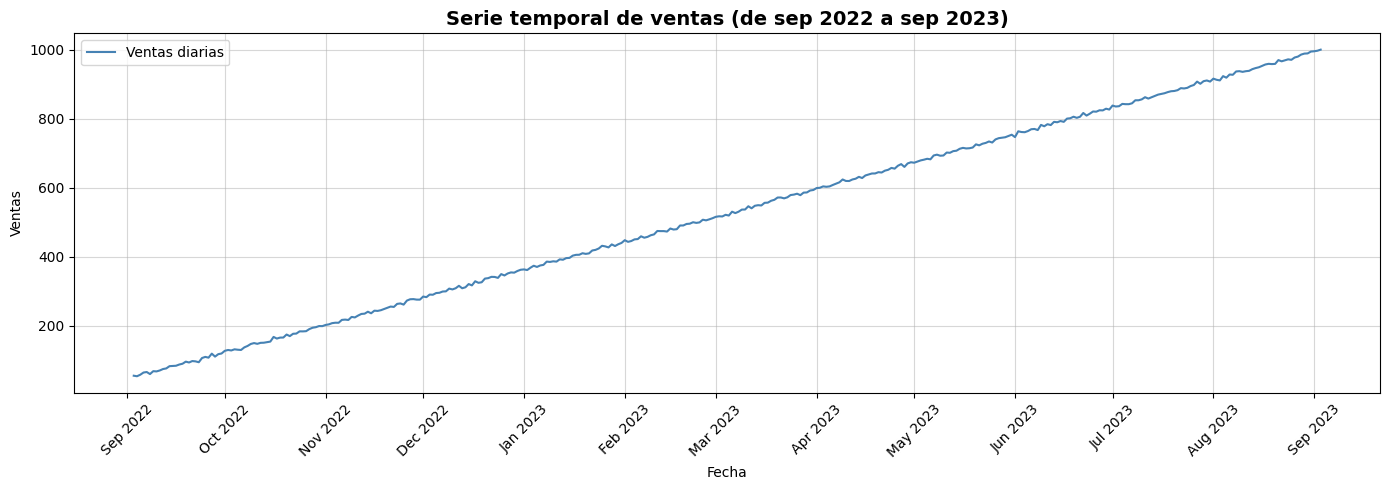

In [12]:
# Gráfico de la serie temporal
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.5, label='Ventas diarias')
ax.set_title('Serie temporal de ventas (de sep 2022 a sep 2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

**Análisis de la serie**

In [ ]:
# TENSOR
freq = pd.infer_freq(ts.index)
print('TENSOR')
print(f'Frecuencia inferida: {freq} - DIARIA (una observación por día)')

diffs = ts.index.to_series().diff().dropna()
print(f'Diferencia media entre registros: {diffs.mean()}')
print(f'Diferencia mínima: {diffs.min()}')
print(f'Diferencia máxima: {diffs.max()}')

TENSOR
Frecuencia inferida: D - DIARIA (una observación por día)
Diferencia media entre registros: 1 days 00:00:00
Diferencia mínima: 1 days 00:00:00
Diferencia máxima: 1 days 00:00:00


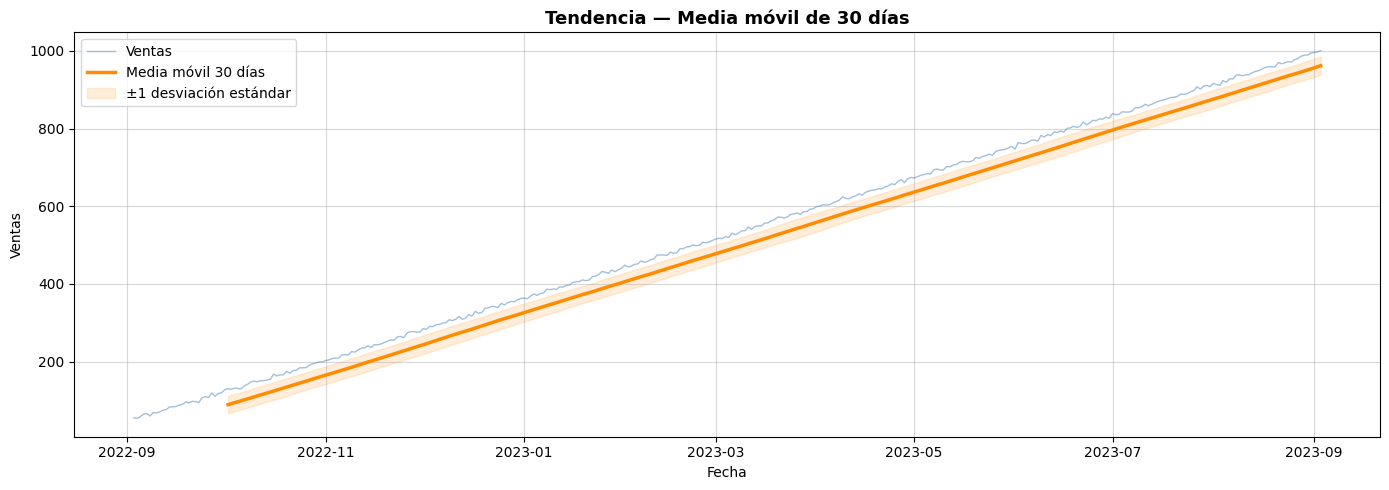


TENDENCIA
Ventas inicio (primeros 30 días): 89.07
Ventas final (últimos 30 días): 961.82
Incremento total: 979.87 %
- Tendencia CRECIENTE clara a lo largo del año.


In [15]:
# TENDENCIA
# Media móvil de 30 días
rolling_mean = ts.rolling(window=30).mean()
rolling_std = ts.rolling(window=30).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts, label='Ventas', color='steelblue', alpha=0.5, linewidth=1)
ax.plot(rolling_mean, label='Media móvil 30 días', color='darkorange', linewidth=2.5)
ax.fill_between(ts.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                alpha=0.15, color='darkorange', label='±1 desviación estándar')
ax.set_title('Tendencia — Media móvil de 30 días', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

print('\nTENDENCIA')
print(f'Ventas inicio (primeros 30 días): {ts[:30].mean():.2f}')
print(f'Ventas final (últimos 30 días): {ts[-30:].mean():.2f}')
print(f'Incremento total: {((ts[-30:].mean() / ts[:30].mean()) - 1)*100:.2f} %')
print('- Tendencia CRECIENTE clara a lo largo del año.')

In [20]:
# ESTACIONARIEDAD - Test ADF
adf_result = adfuller(ts, autolag='AIC')

print('TEST AUGMENTED DICKEY-FULLER (ADF)')
print(f'Estadístico ADF: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print(f'Valores críticos:')

for k, v in adf_result[4].items():
    print(f'{k}: {v}')

if adf_result[1] < 0.05:
    print('\nResultado: p < 0.05 - Se rechaza H0 - La serie es estacionaria.')
else:
    print('\nResultado: p ≥ 0.05 - No se rechaza H0 - La serie no es estacionaria.')

TEST AUGMENTED DICKEY-FULLER (ADF)
Estadístico ADF: 0.545414193706378
p-value: 0.9861899815311064
Valores críticos:
1%: -3.4490648539347544
5%: -2.8697861692116478
10%: -2.5711631253228306

Resultado: p ≥ 0.05 - No se rechaza H0 - La serie no es estacionaria.


VARIABILIDAD / RUIDO
Desviación estándar: 275.08969801796553
CV (std/mean): 52.40 %


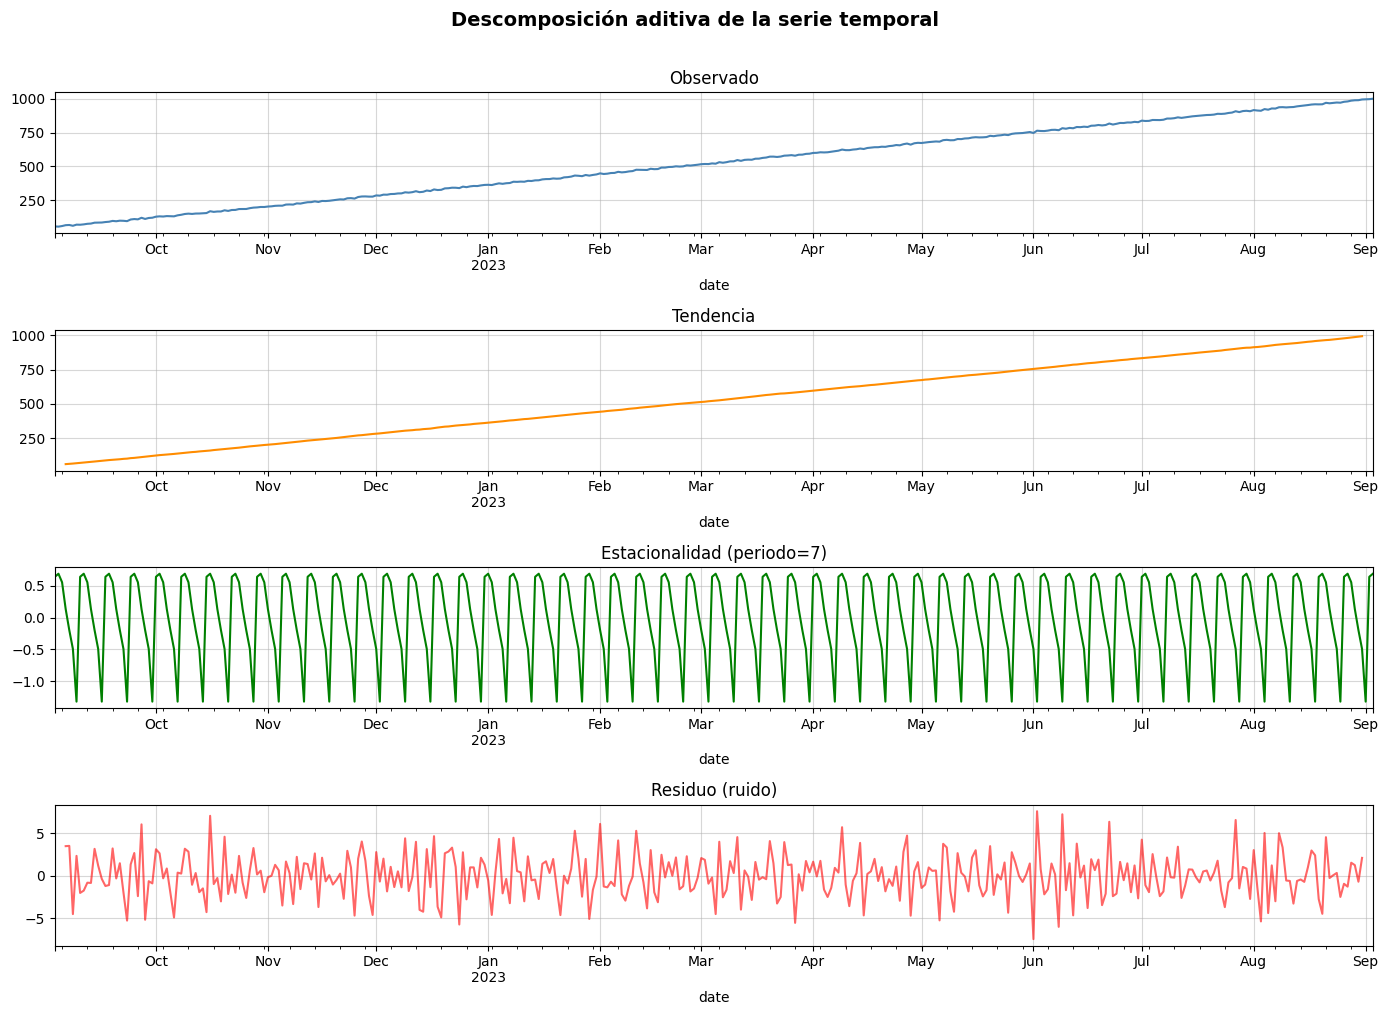


Desviación estándar del residuo: 2.6105392680278854
- Hay variabilidad moderada; el ruido es estacionario alrededor de 0.


In [23]:
# VARIABILIDAD Y RUIDO
print('VARIABILIDAD / RUIDO')
print(f'Desviación estándar: {ts.std()}')
print(f'CV (std/mean): {ts.std()/ts.mean()*100:.2f} %')

# Descomposición aditiva
decomp = seasonal_decompose(ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observado', color='steelblue')
decomp.trend.plot (ax=axes[1], title='Tendencia', color='darkorange')
decomp.seasonal.plot(ax=axes[2], title='Estacionalidad (periodo=7)', color='green')
decomp.resid.plot(ax=axes[3], title='Residuo (ruido)', color='red', alpha=0.6)
for ax in axes:
    ax.grid(alpha=0.5)
plt.suptitle('Descomposición aditiva de la serie temporal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

residuo_std = decomp.resid.dropna().std()
print(f'\nDesviación estándar del residuo: {residuo_std}')
print('- Hay variabilidad moderada; el ruido es estacionario alrededor de 0.')

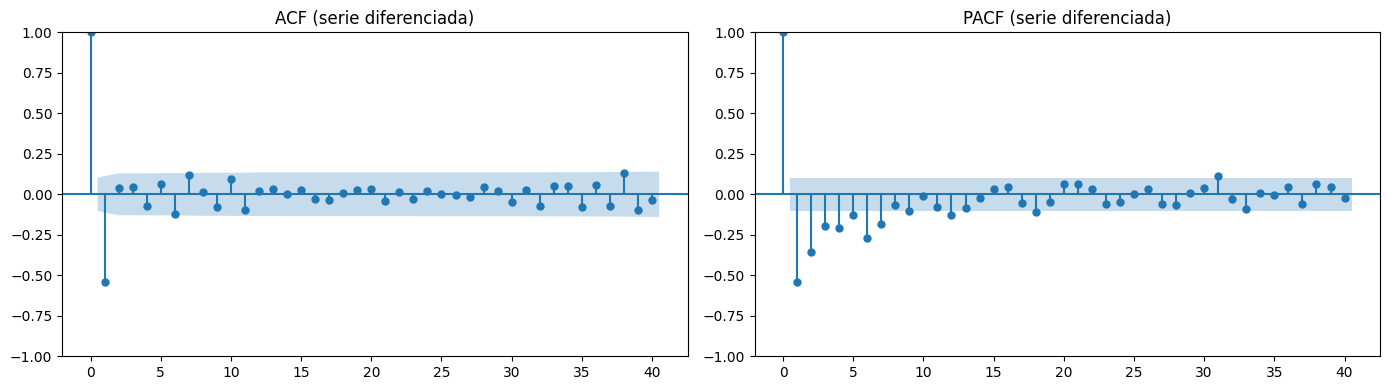

In [24]:
# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts.diff().dropna(), lags=40, ax=axes[0], title='ACF (serie diferenciada)')
plot_pacf(ts.diff().dropna(), lags=40, ax=axes[1], title='PACF (serie diferenciada)')
plt.tight_layout()
plt.show()

**RESPUESTAS AL ANÁLISIS**
- **¿Cuál es el tensor de la serie temporal?** Diario (una observación por día durante 366 días).
- **¿Cuál es la tendencia?** Creciente (las ventas aumentan de alrededor de 55 a alrededor de 1000 a lo largo del año).
- **¿Es estacionaria?** La serie no es estacionaria. El test ADF lo confirma.
- **¿Existe variabilidad o presencia de ruido?** Sí existe: CV = 52.40 %.

**Paso 3: Entrenamiento del modelo ARIMA**

In [26]:
# Split train y test (80/20)
split = int(len(ts) * 0.8)
train = ts.iloc[:split]
test = ts.iloc[split:]

print(f'Tamaño del conjunto train: {len(train)} observaciones ({train.index.min().date()} - {train.index.max().date()})')
print(f'Tamaño del conjunto test: {len(test)} observaciones ({test.index.min().date()} - {test.index.max().date()})')

Tamaño del conjunto train: 292 observaciones (2022-09-03 - 2023-06-21)
Tamaño del conjunto test: 74 observaciones (2023-06-22 - 2023-09-03)


In [28]:
# Auto-ARIMA para encontrar los mejores parámetros
print('Buscando los mejores parámetros ARIMA con auto_arima...')
auto_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)

print(f'\nMEJOR MODELO')
print(f'Orden (p, d, q): {auto_model.order}')
print(f'AIC: {auto_model.aic():.2f}')
print(auto_model.summary())

Buscando los mejores parámetros ARIMA con auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1675.428, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1578.564, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1475.165, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1763.761, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1475.512, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1475.495, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1479.028, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1762.924, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.812 seconds

MEJOR MODELO
Orden (p, d, q): (0, 1, 1)
AIC: 1475.16
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  292
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -734.582
Date:

In [29]:
# Entrenar ARIMA final
p, d, q = auto_model.order
model = ARIMA(train, order=(p, d, q))
fitted_model = model.fit()
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -879.462
Date:                Thu, 16 Apr 2026   AIC                           1762.924
Time:                        17:53:31   BIC                           1770.271
Sample:                    09-03-2022   HQIC                          1765.867
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0758      0.077     -0.981      0.326      -0.227       0.076
sigma2        24.6927      2.048     12.056      0.000      20.679      28.707
Ljung-Box (L1) (Q):                  73.69   Jarque-

**Paso 4: Predicción y evaluación**

In [30]:
# Predicción sobre el conjunto test
forecast = fitted_model.forecast(steps=len(test))
forecast.index = test.index

In [31]:
# Métricas
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print('MÉTRICAS DE RENDIMIENTO')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MÉTRICAS DE RENDIMIENTO
MAE: 98.86
RMSE: 113.38


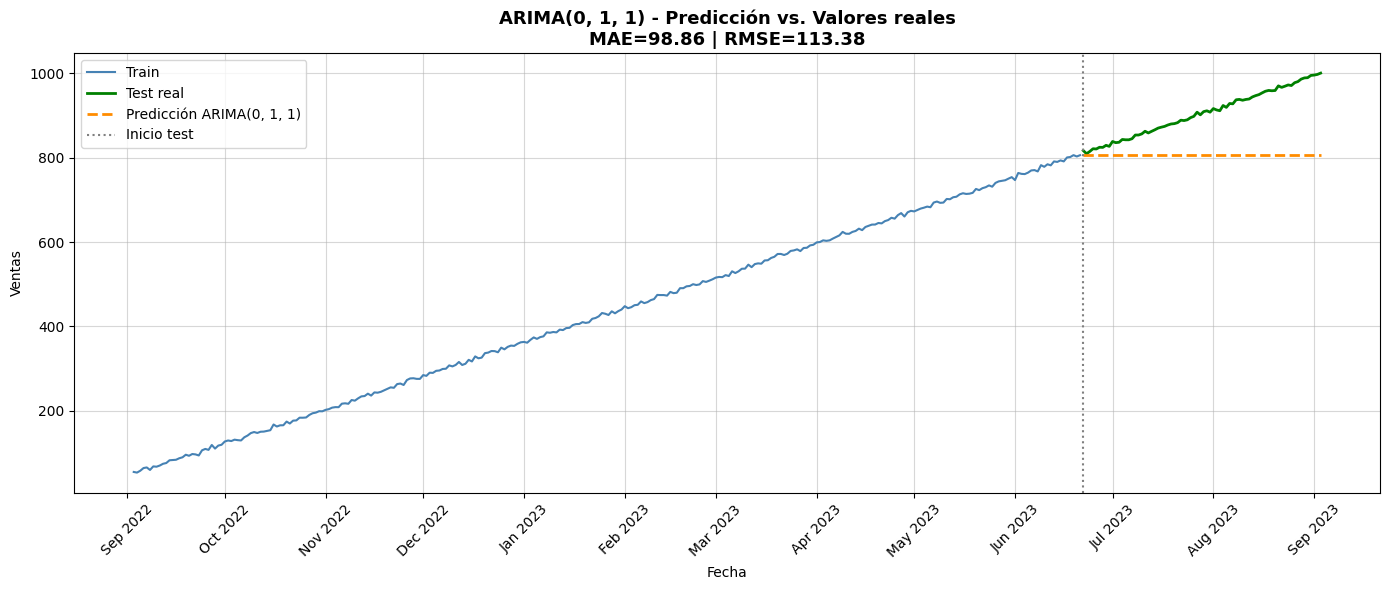

In [33]:
# Gráfico: Predicción vs. Valores reales
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test.index,  test.values,  label='Test real', color='green', linewidth=2)
ax.plot(forecast.index, forecast.values,
        label=f'Predicción ARIMA{auto_model.order}',
        color='darkorange', linewidth=2, linestyle='--')
ax.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Inicio test')
ax.set_title(f'ARIMA{auto_model.order} - Predicción vs. Valores reales\nMAE={mae:.2f} | RMSE={rmse:.2f}', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

**Paso 5: Guardar el modelo**

In [34]:
# Guardo el modelo
os.makedirs('/workspaces/alemantellini-machine-learning/models', exist_ok=True)
model_path = f'/workspaces/alemantellini-machine-learning/models/arima_{p}_{d}_{q}.pkl'
joblib.dump(fitted_model, model_path)
print(f'Modelo guardado en: {model_path}')

# Verifico que se puede cargar
loaded = joblib.load(model_path)
print(f'Modelo cargado correctamente. Tipo: {type(loaded)}')

Modelo guardado en: /workspaces/alemantellini-machine-learning/models/arima_0_1_1.pkl
Modelo cargado correctamente. Tipo: <class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>


**CONCLUSIONES**
- **¿Cuál es el tensor de la serie temporal?** Diario (una observación por día durante 366 días).
- **¿Cuál es la tendencia?** Creciente (las ventas aumentan de alrededor de 55 a alrededor de 1000 a lo largo del año).
- **¿Es estacionaria?** La serie no es estacionaria. El test ADF lo confirma.
- **¿Existe variabilidad o presencia de ruido?** Sí existe: CV = 52.40 %.
- **Mejor modelo:** ARIMA(0,1,1)(0,0,0)[0] intercept.
- **MAE:** 98.86
- **RMSE:** 113.38
- **Modelo guardado:** models/arima_0_1_1.pkl